# Loan Approval — Final Modeling Pipeline

Models selected from `2_Experiments.ipynb`: **Gradient Boosting** for both classification and regression.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, r2_score

## 1. Load & Clean Data

In [3]:
df = pd.read_csv('archive/loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
df.drop(columns=['loan_id'], errors='ignore', inplace=True)

cat_cols_all = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
df[cat_cols_all] = df[cat_cols_all].apply(lambda col: col.astype(str).str.strip().str.lower())

print('Shape:', df.shape)
df.head(2)

Shape: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,graduate,no,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
1,0,not graduate,yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected


## 2. Shared Preprocessing Transformers

In [4]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## 3. Stage 1 — Classification (Approved / Rejected)

In [5]:
# loan_amount stays as a feature — bank sees the requested amount when deciding
X_clf = df.drop(columns=['loan_status'])
y_clf = (df['loan_status'] == 'approved').astype(int)

cat_cols_clf = X_clf.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
num_cols_clf = X_clf.select_dtypes(include=[np.number]).columns.tolist()

clf_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_clf),
    ('cat', categorical_transformer, cat_cols_clf)
], remainder='drop')

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print('Train:', X_clf_train.shape, '| Test:', X_clf_test.shape)
print('Class distribution:', y_clf_train.value_counts().to_dict())

Train: (3415, 11) | Test: (854, 11)
Class distribution: {1: 2125, 0: 1290}


In [6]:
clf_pipeline = Pipeline(steps=[
    ('preprocessor', clf_preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

clf_param_grid = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [3, 4, 5],
    'model__learning_rate':   [0.05, 0.1, 0.2],
    'model__min_samples_split': [2, 5]
}

grid_clf = GridSearchCV(clf_pipeline, clf_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_clf.fit(X_clf_train, y_clf_train)
print('Best params:', grid_clf.best_params_)
print('Best CV F1: ', round(grid_clf.best_score_, 4))

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/dq/d4yy_ys964v31clg74x7vffr0000gn/T/joblib_memmapping_folder_1894_814f5f28ef83482d8aab8eae67cf6872_2df1ddeb92b148b2ac0f4348ee61618f for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-1894-0j9of3on for automatic cleanup: unknown resource type semlock
Traceback (most recent call last

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV F1:  0.9866


In [7]:
best_clf = grid_clf.best_estimator_
y_clf_pred = best_clf.predict(X_clf_test)
print(classification_report(y_clf_test, y_clf_pred, target_names=['rejected', 'approved']))

              precision    recall  f1-score   support

    rejected       0.99      0.97      0.98       323
    approved       0.98      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.98      0.99       854
weighted avg       0.99      0.99      0.99       854



### Feature Importance — Classifier

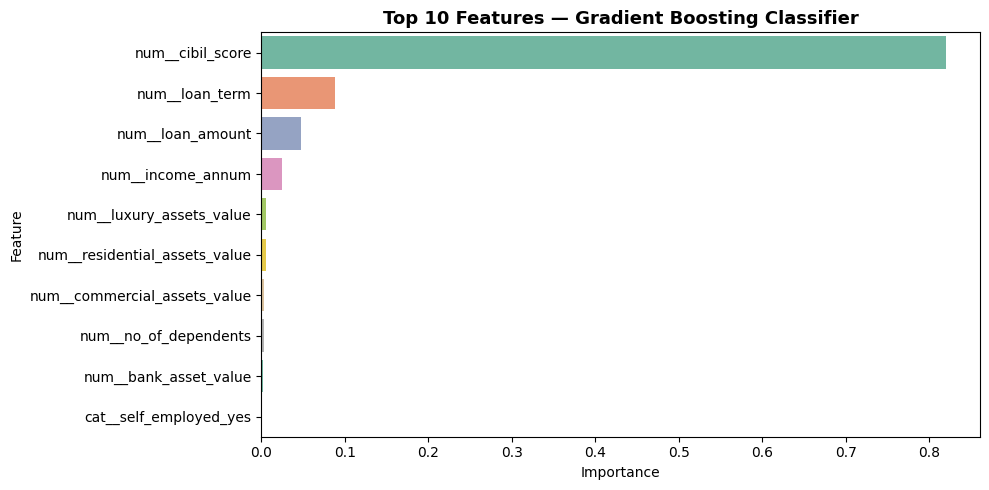

In [8]:
clf_feature_names = best_clf.named_steps['preprocessor'].get_feature_names_out()
clf_importances = best_clf.named_steps['model'].feature_importances_

clf_imp_df = pd.DataFrame({'Feature': clf_feature_names, 'Importance': clf_importances})
clf_imp_df = clf_imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=clf_imp_df, x='Importance', y='Feature', palette='Set2')
plt.title('Top 10 Features — Gradient Boosting Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Stage 2 — Regression (Predict Loan Amount for Approved Loans)

In [9]:
# Train on approved loans only — loan_amount is now the target, not a feature
approved_df = df[df['loan_status'] == 'approved'].copy()

X_reg = approved_df.drop(columns=['loan_status', 'loan_amount'])
y_reg = approved_df['loan_amount']

cat_cols_reg = X_reg.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_reg),
    ('cat', categorical_transformer, cat_cols_reg)
], remainder='drop')

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print('Train:', X_reg_train.shape, '| Test:', X_reg_test.shape)

Train: (2124, 10) | Test: (532, 10)


In [10]:
reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

reg_param_grid = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [3, 4, 5],
    'model__learning_rate':     [0.05, 0.1, 0.2],
    'model__min_samples_split': [2, 5]
}

grid_reg = GridSearchCV(reg_pipeline, reg_param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_reg.fit(X_reg_train, y_reg_train)
print('Best params:', grid_reg.best_params_)
print('Best CV R²: ', round(grid_reg.best_score_, 4))

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/dq/d4yy_ys964v31clg74x7vffr0000gn/T/joblib_memmapping_folder_1894_4265b39b68ac49daabafeecea9725afd_bd1b54d9d36c443695aa4d1466fac473 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/dq/d4yy_ys964v31clg74x7vffr0000gn/T/joblib_memmapping_folder_1894_814f5f28ef83482d8aab8eae67

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV R²:  0.8693


In [11]:
best_reg = grid_reg.best_estimator_
y_reg_pred = best_reg.predict(X_reg_test)

print(f'R²:   {r2_score(y_reg_test, y_reg_pred):.4f}')
print(f'MAE:  {mean_absolute_error(y_reg_test, y_reg_pred):,.0f}')
print(f'RMSE: {mean_squared_error(y_reg_test, y_reg_pred) ** 0.5:,.0f}')

R²:   0.8783
MAE:  2,445,062
RMSE: 3,234,075


### Feature Importance — Regressor

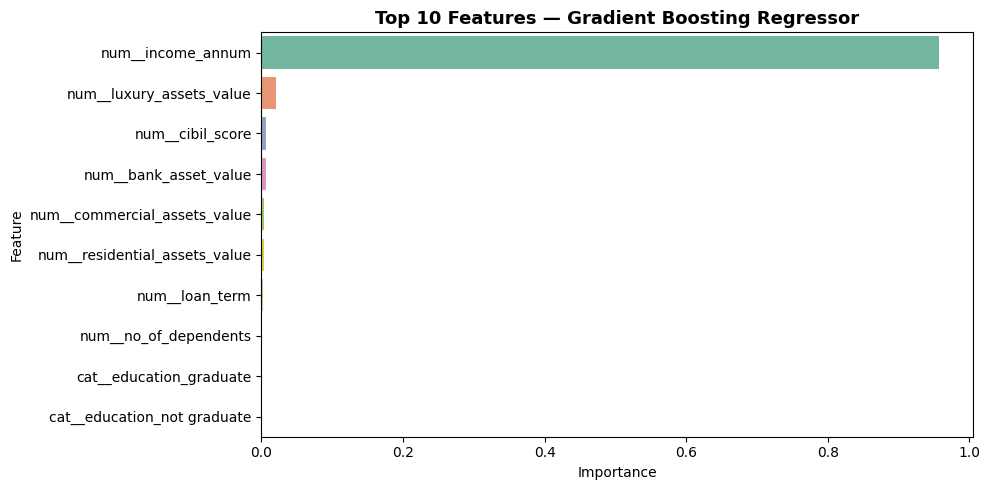

In [12]:
reg_feature_names = best_reg.named_steps['preprocessor'].get_feature_names_out()
reg_importances = best_reg.named_steps['model'].feature_importances_

reg_imp_df = pd.DataFrame({'Feature': reg_feature_names, 'Importance': reg_importances})
reg_imp_df = reg_imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=reg_imp_df, x='Importance', y='Feature', palette='Set2')
plt.title('Top 10 Features — Gradient Boosting Regressor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Save Artifacts

In [13]:
joblib.dump(best_clf, 'models/stage_1_gb_classifier.pkl')
joblib.dump(best_reg, 'models/stage_2_gb_regressor.pkl')
print('Models saved.')

Models saved.


## 6. Two-Stage Prediction Function

In [14]:
clf = joblib.load('models/stage_1_gb_classifier.pkl')
reg = joblib.load('models/stage_2_gb_regressor.pkl')

def two_stage_predict(applicant_df):
    approved = clf.predict(applicant_df)[0]
    result = {'loan_status': 'approved' if approved else 'rejected'}
    if approved:
        reg_input = applicant_df.drop(columns=['loan_amount'], errors='ignore')
        result['predicted_loan_amount'] = round(float(reg.predict(reg_input)[0]), 2)
    return result

In [ ]:
sample = pd.DataFrame([{
    'no_of_dependents':          1,
    'education':                 'graduate',
    'self_employed':             'no',
    'income_annum':              1_200_000,
    'loan_amount':               300_000,
    'loan_term':                 12,
    'cibil_score':               800,
    'residential_assets_value':  2_000_000,
    'commercial_assets_value':   2_000_000,
    'luxury_assets_value':       0,
    'bank_asset_value':          55_000
}])

two_stage_predict(sample)

{'loan_status': 'approved', 'predicted_loan_amount': 3657051.89}

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-1894-7_6krrrk for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-1894-vhz7oykc for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessi